# Explainable AI: Zero to Hero

Five methods that answer "why did the model do that?", the measured extent to which they
disagree with each other, and an honest look at whether you needed the black box at all.

> **Prerequisites:** [`random_forest_zero_to_hero.ipynb`](random_forest_zero_to_hero.ipynb)
> §on feature importance is the shortest version of this notebook's central problem, and
> [`linear_regression_zero_to_hero.ipynb`](linear_regression_zero_to_hero.ipynb) Q10 is the
> omitted-variable argument §1.8 builds on. You should have met tree ensembles (NB-04, NB-05)
> before reading this.

***

## Why this notebook is uncomfortable

Explanation methods are usually presented as a solved problem: fit the model, call `shap`,
show the bar chart. Measured against each other, they behave less tidily:

- **The methods disagree, and one disagrees violently.** §2.3 ranks eight features five ways on
  the same model. MDI, permutation importance and SHAP correlate at **0.90–0.98** — and
  **drop-column importance correlates with them at 0.05**, ranking the others' top feature
  **dead last**. Neither answer is wrong; they answer different questions (§1.4).
- **Correlated features break importance, including SHAP.** §1.3 duplicates one feature three
  times and watches permutation importance for it collapse from **1.514 to 0.393** — below a
  feature with half its true coefficient. §3.2 shows SHAP degrading more gracefully but still
  producing a misleading chart.
- **A partial dependence plot can be flat when the effect is large.** §1.5 builds a feature
  with a strong effect in both directions: the PDP spans **0.71** and the individual ICE curves
  span **10.68** — fifteen times more.
- **And the model you are explaining may not be the one you should have shipped.** §3.4 finds
  logistic regression beating a 300-tree random forest on the same data — **0.9807 to
  0.9614**. There was nothing to explain, because there was no reason for the black box.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports (adds `shap` and `lime`) |
| **1. Theory from zero** | Global vs local · permutation importance · **the correlated-feature problem** · drop-column and the two questions · **PDP and ICE** · **SHAP and additivity** · LIME · **importance is not causation** |
| **2. Worked example** | California housing — five methods on one model |
| **3. The uncomfortable parts** | Why they disagree · what correlation does to SHAP · surrogates · **Rudin's counterpoint** |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | XAI-specific errors and a checklist |

## The one-paragraph summary

Explanation methods come in two families. **Global** methods describe the model overall —
permutation importance, drop-column importance, partial dependence. **Local** methods explain
one prediction — SHAP, LIME, counterfactuals. Each is defined by a different question, so when
they disagree it is usually because you asked several questions and read the answers as if they
were one. The failure they share is **correlated features**: every method must decide what to
hold fixed while it varies something, and when features move together there is no honest way to
do that. None of them recovers **causation**, and none of them tells you whether a simpler,
inherently interpretable model would have done the job.

***
# Part 0 - Setup

Two extra dependencies: **`shap`** and **`lime`**. Both are used to *check* the from-scratch
implementations rather than to replace them, so the material survives if you cannot install
either.

One wrinkle worth naming: `import shap` emits a matplotlib deprecation warning from inside the
library. This notebook is verified with warnings treated as errors, so the import is wrapped in
a targeted suppression — there is nothing to fix on our side.

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
    ("shap", "shap"), ("lime", "lime"),         # new for this notebook
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

installing: shap, lime
done


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_diabetes
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import (
    permutation_importance, partial_dependence, PartialDependenceDisplay,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import r2_score, accuracy_score

# shap 0.52 calls matplotlib's deprecated Colormap.set_bad while importing its plotting
# module. The warning comes from inside the library, so it is suppressed here, once,
# around the import only.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    import shap
    from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| shap", shap.__version__)

ready | numpy 2.5.2 | shap 0.52.0


***
# Part 1 - Theory from zero

1. What "explain" means, and the two families
2. Permutation importance
3. **The correlated-feature problem**
4. Drop-column importance, and the two different questions
5. **Partial dependence and ICE**
6. **SHAP: Shapley values and the additivity axiom**
7. LIME, and how stable it is
8. **Importance is not causation**

## 1.1 Two families, several questions

"Explain the model" is not one request. At minimum it is two:

- **Global** — *what does this model do in general?* Which features drive it, and in what
  direction. Audiences: model reviewers, regulators, your own debugging.
- **Local** — *why did it say that about this row?* Audiences: the person affected by the
  decision, and the support agent who has to justify it.

A method built for one answers the other badly. And within each family, methods differ in what
they hold fixed, what they perturb, and whether they refit — which is why they disagree (§2.3).

| Method | Family | Refits? | Answers |
|---|---|---|---|
| **MDI** (tree impurity) | global | no | how much did splits on this feature reduce impurity *during training*? |
| **Permutation importance** | global | no | how much worse does the fitted model get if this feature is scrambled? |
| **Drop-column** | global | **yes** | how much worse would a model be if this feature did not exist? |
| **Partial dependence / ICE** | global | no | how does the prediction change as this feature varies? |
| **SHAP** | **local** (aggregable) | no | how much did each feature contribute to *this* prediction? |
| **LIME** | **local** | no (fits a local surrogate) | what simple model approximates the black box *near this point*? |

Keep that table in view. Most confusion about explanation methods is people comparing answers
to different questions.

In [3]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=RANDOM_STATE)
FEATURES = list(X.columns)

rf = RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE,
                           n_jobs=-1)
rf.fit(X_train, y_train)

print(f"California housing: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"target: median house value in $100,000s\n")
print(f"random forest R2 : train {rf.score(X_train, y_train):.4f}   "
      f"test {rf.score(X_test, y_test):.4f}")
print("\nfeatures:")
for f in FEATURES:
    print(f"  {f:<12} {data.frame[f].describe()[['mean', 'min', 'max']].round(2).to_dict()}")
print()
print("This is the model every method in Part 1 will be asked to explain. It is deliberately")
print("a black box - 120 trees of depth 12 is roughly 100,000 decision nodes, and no human")
print("reads that.")

California housing: 20,640 rows, 8 features
target: median house value in $100,000s

random forest R2 : train 0.9208   test 0.7957

features:
  MedInc       {'mean': 3.87, 'min': 0.5, 'max': 15.0}
  HouseAge     {'mean': 28.64, 'min': 1.0, 'max': 52.0}
  AveRooms     {'mean': 5.43, 'min': 0.85, 'max': 141.91}
  AveBedrms    {'mean': 1.1, 'min': 0.33, 'max': 34.07}
  Population   {'mean': 1425.48, 'min': 3.0, 'max': 35682.0}
  AveOccup     {'mean': 3.07, 'min': 0.69, 'max': 1243.33}
  Latitude     {'mean': 35.63, 'min': 32.54, 'max': 41.95}
  Longitude    {'mean': -119.57, 'min': -124.35, 'max': -114.31}

This is the model every method in Part 1 will be asked to explain. It is deliberately
a black box - 120 trees of depth 12 is roughly 100,000 decision nodes, and no human
reads that.


## 1.2 Permutation importance

The most useful global method, and the easiest to reason about:

1. Score the fitted model.
2. Shuffle one column, breaking its relationship with the target while keeping its marginal
   distribution.
3. Score again. The drop is that feature's importance.
4. Put the column back, repeat for the next.

Two properties matter. It is **model-agnostic** — anything with a `predict` works. And it
measures **the fitted model's reliance**, not the feature's value in principle: nothing is
refitted, so the answer is about this model, not this problem.

In [4]:
def permutation_importance_from_scratch(model, X_, y_, n_repeats=5, seed=0):
    """Shuffle one column at a time and measure the score drop."""
    rng = np.random.default_rng(seed)
    baseline = r2_score(y_, model.predict(X_))
    out = {}
    for col in X_.columns:
        drops = []
        for _ in range(n_repeats):
            Xp = X_.copy()
            Xp[col] = rng.permutation(Xp[col].to_numpy())
            drops.append(baseline - r2_score(y_, model.predict(Xp)))
        out[col] = float(np.mean(drops))
    return pd.Series(out), baseline


X_small, y_small = X_test.iloc[:2000], y_test.iloc[:2000]
mine, base_score = permutation_importance_from_scratch(rf, X_small, y_small,
                                                       n_repeats=5, seed=RANDOM_STATE)
sk = permutation_importance(rf, X_small, y_small, n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
theirs = pd.Series(sk.importances_mean, index=FEATURES)

print(f"baseline R2 on the held-out rows: {base_score:.4f}\n")
comp = pd.DataFrame({"mine": mine, "sklearn": theirs,
                     "sklearn std": sk.importances_std}).sort_values("sklearn",
                                                                     ascending=False)
print(comp.round(4).to_string())
print(f"\nrank correlation between the two: "
      f"{spearmanr(comp['mine'], comp['sklearn']).statistic:.4f}")
print()
print("Two things to take from the std column.")
print()
print("  1. Permutation importance is STOCHASTIC. Always run several repeats and look at the")
print("     spread - a difference smaller than the std is not a difference.")
print("  2. Features whose importance is within noise of zero are not 'slightly useful'.")
print("     They are indistinguishable from useless to this model.")

baseline R2 on the held-out rows: 0.7922

              mine  sklearn  sklearn std
MedInc      0.7830   0.7749       0.0360
Latitude    0.3834   0.3750       0.0138
Longitude   0.2799   0.2866       0.0074
AveOccup    0.2073   0.2051       0.0035
HouseAge    0.0718   0.0677       0.0025
AveRooms    0.0237   0.0241       0.0026
Population  0.0097   0.0103       0.0016
AveBedrms   0.0091   0.0077       0.0027

rank correlation between the two: 1.0000

Two things to take from the std column.

  1. Permutation importance is STOCHASTIC. Always run several repeats and look at the
     spread - a difference smaller than the std is not a difference.
  2. Features whose importance is within noise of zero are not 'slightly useful'.
     They are indistinguishable from useless to this model.


            on test  on train
MedInc       0.7707    0.8851
Latitude     0.3729    0.4175
Longitude    0.2897    0.2899
AveOccup     0.2055    0.2532
HouseAge     0.0678    0.1050
AveRooms     0.0236    0.0509
Population   0.0099    0.0282
AveBedrms    0.0076    0.0310

rank correlation: 0.9762


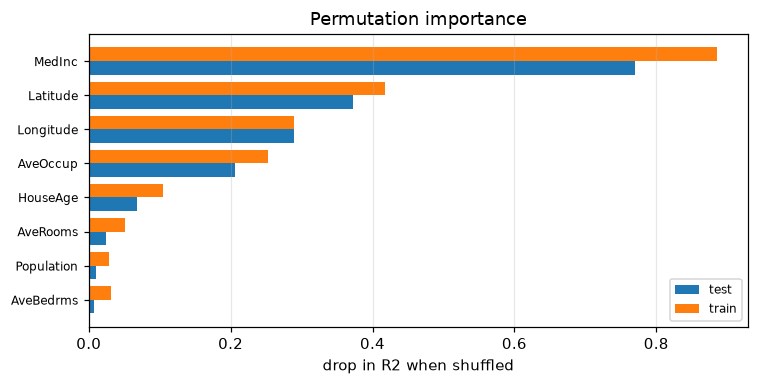


Which to use depends on the question:
  ON TEST  - which features drive the model's GENERALISATION? Use this by default.
  ON TRAIN - which features did the model LEARN to rely on, including by memorising?

A feature important on train and unimportant on test is one the model overfitted to.
That gap is a genuinely useful overfitting diagnostic, and it is free once you have
computed both.


In [5]:
# On train or on test? They answer different questions, and the gap is diagnostic.
perm_test = permutation_importance(rf, X_test.iloc[:2000], y_test.iloc[:2000],
                                   n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
perm_train = permutation_importance(rf, X_train.iloc[:2000], y_train.iloc[:2000],
                                    n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
cmp2 = pd.DataFrame({"on test": perm_test.importances_mean,
                     "on train": perm_train.importances_mean},
                    index=FEATURES).sort_values("on test", ascending=False)
print(cmp2.round(4).to_string())
print(f"\nrank correlation: {spearmanr(cmp2['on test'], cmp2['on train']).statistic:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
order = cmp2.index[::-1]
ax.barh(np.arange(len(order)) - 0.2, cmp2.loc[order, "on test"], height=0.4, label="test")
ax.barh(np.arange(len(order)) + 0.2, cmp2.loc[order, "on train"], height=0.4, label="train")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("drop in R2 when shuffled"); ax.set_title("Permutation importance")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

print()
print("Which to use depends on the question:")
print("  ON TEST  - which features drive the model's GENERALISATION? Use this by default.")
print("  ON TRAIN - which features did the model LEARN to rely on, including by memorising?")
print()
print("A feature important on train and unimportant on test is one the model overfitted to.")
print("That gap is a genuinely useful overfitting diagnostic, and it is free once you have")
print("computed both.")

## 1.3 The correlated-feature problem

This is the failure that runs through every method in the notebook, so it is worth seeing in a
case where the truth is known exactly.

Permutation importance shuffles **one** column while the others keep their real values. If two
columns carry the same information, shuffling either one leaves the model able to recover it
from the other — so both look unimportant, and the total attributed to that information
collapses.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
n = 4000
a = rng.normal(size=n)
b = rng.normal(size=n)
noise = rng.normal(size=n)
y_syn = 3 * a + 1.5 * b + 0.3 * noise          # a matters TWICE as much as b

print("ground truth: y = 3*a + 1.5*b + 0.3*noise")
print("so 'a' should always rank above 'b'.\n")
print(f"{'features given to the model':<32} {'permutation importance'}")
print("-" * 96)
for label, frame in [
    ("a, b, noise", pd.DataFrame({"a": a, "b": b, "noise": noise})),
    ("+ one exact copy of a",
     pd.DataFrame({"a": a, "b": b, "noise": noise, "a_copy": a})),
    ("+ three exact copies of a",
     pd.DataFrame({"a": a, "b": b, "noise": noise, "a1": a, "a2": a, "a3": a})),
    ("+ a near-copy (a + tiny noise)",
     pd.DataFrame({"a": a, "b": b, "noise": noise,
                   "a_noisy": a + 0.01 * rng.normal(size=n)})),
]:
    Xa, Xb, ya, yb = train_test_split(frame, y_syn, test_size=0.25,
                                      random_state=RANDOM_STATE)
    m = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(Xa, ya)
    p = permutation_importance(m, Xb, yb, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
    s = pd.Series(p.importances_mean, index=frame.columns).sort_values(ascending=False)
    a_total = sum(v for k, v in s.items() if k.startswith("a"))
    print(f"{label:<32} " + "  ".join(f"{k}={v:.3f}" for k, v in s.items()))
    print(f"{'':<32} R2 {m.score(Xb, yb):.4f} | total for all 'a' columns: "
          f"{a_total:.3f} | b: {s['b']:.3f}")

print()
print("Follow the total for 'a' down the page: 1.514, then 0.801, then 0.393.")
print()
print("With three copies, the total attributed to 'a' has fallen BELOW 'b' - so a bar chart")
print("would tell you b is the more important feature, when a's true coefficient is twice")
print("b's. The model's R2 is unchanged throughout; only the explanation moved.")
print()
print("Note the last row: the copy does not have to be exact. Adding 1% noise makes it a")
print("distinct column that still splits the importance almost as badly.")
print()
print("This is not a bug in permutation importance. Shuffling asks 'what if this column were")
print("uninformative?' - and when a duplicate is present, the answer is honestly 'nothing")
print("much'. The question is just not the one you meant to ask.")

ground truth: y = 3*a + 1.5*b + 0.3*noise
so 'a' should always rank above 'b'.

features given to the model      permutation importance
------------------------------------------------------------------------------------------------
a, b, noise                      a=1.514  b=0.411  noise=0.009
                                 R2 0.9958 | total for all 'a' columns: 1.514 | b: 0.411
+ one exact copy of a            a=0.445  b=0.411  a_copy=0.356  noise=0.009
                                 R2 0.9958 | total for all 'a' columns: 0.801 | b: 0.411
+ three exact copies of a        b=0.411  a=0.108  a2=0.107  a3=0.093  a1=0.084  noise=0.009
                                 R2 0.9958 | total for all 'a' columns: 0.393 | b: 0.411
+ a near-copy (a + tiny noise)   a=0.470  b=0.411  a_noisy=0.341  noise=0.009
                                 R2 0.9958 | total for all 'a' columns: 0.811 | b: 0.411

Follow the total for 'a' down the page: 1.514, then 0.801, then 0.393.

With three copies, the tota

## 1.4 Drop-column importance

The obvious fix: instead of shuffling a feature, **remove it and refit**. That answers "how
much worse would a model be without this feature?", which is often the question people
actually mean.

It costs one refit per feature, and — as §2.3 will show dramatically — it can rank features
completely differently from every other method.

In [7]:
def drop_column_importance(make_model, X_tr, y_tr, X_te, y_te):
    """Refit without each column; importance = the loss in score."""
    full = make_model().fit(X_tr, y_tr).score(X_te, y_te)
    out = {}
    for col in X_tr.columns:
        keep = [c for c in X_tr.columns if c != col]
        out[col] = full - make_model().fit(X_tr[keep], y_tr).score(X_te[keep], y_te)
    return pd.Series(out), full


def small_forest():
    return RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)


frame3 = pd.DataFrame({"a": a, "b": b, "noise": noise, "a1": a, "a2": a, "a3": a})
Xa, Xb, ya, yb = train_test_split(frame3, y_syn, test_size=0.25, random_state=RANDOM_STATE)
dc, full_score = drop_column_importance(small_forest, Xa, ya, Xb, yb)
pi = pd.Series(permutation_importance(small_forest().fit(Xa, ya), Xb, yb, n_repeats=8,
                                      random_state=RANDOM_STATE,
                                      n_jobs=-1).importances_mean, index=frame3.columns)

print("the same 'three copies of a' dataset, both methods:\n")
print(pd.DataFrame({"permutation": pi, "drop-column": dc}).round(4).to_string())
print()
print("Drop-column says the SAME thing here, and for the same reason: removing one copy of")
print("'a' costs nothing, because three more remain. Refitting does not rescue you from")
print("redundancy.")
print()
print("What drop-column measures that permutation does not: whether the information is")
print("AVAILABLE ELSEWHERE. That distinction is the whole of 2.3.")
print()
print("Its costs are real: one refit per feature (expensive), the refit model is a DIFFERENT")
print("model (so you are no longer explaining the one you shipped), and with correlated")
print("features it systematically under-credits everything.")

the same 'three copies of a' dataset, both methods:

       permutation  drop-column
a           0.1077       0.0000
b           0.4115       0.2431
noise       0.0093       0.0072
a1          0.0842      -0.0000
a2          0.1075      -0.0000
a3          0.0932      -0.0000

Drop-column says the SAME thing here, and for the same reason: removing one copy of
'a' costs nothing, because three more remain. Refitting does not rescue you from
redundancy.

What drop-column measures that permutation does not: whether the information is
AVAILABLE ELSEWHERE. That distinction is the whole of 2.3.

Its costs are real: one refit per feature (expensive), the refit model is a DIFFERENT
model (so you are no longer explaining the one you shipped), and with correlated
features it systematically under-credits everything.


## 1.5 Partial dependence and ICE

A **partial dependence plot** answers: as feature $j$ varies, how does the average prediction
change? Sweep $j$ across a grid, and for each value average the model's prediction over all the
*observed* values of the other features.

An **ICE plot** (individual conditional expectation) draws the same sweep for each row
separately, without averaging.

The difference between them is not cosmetic. Averaging can cancel out an effect entirely.

truth: y = +2*x1 for group 1, -2*x1 for group 0.
x1 has a large effect on everyone, and NO average effect.



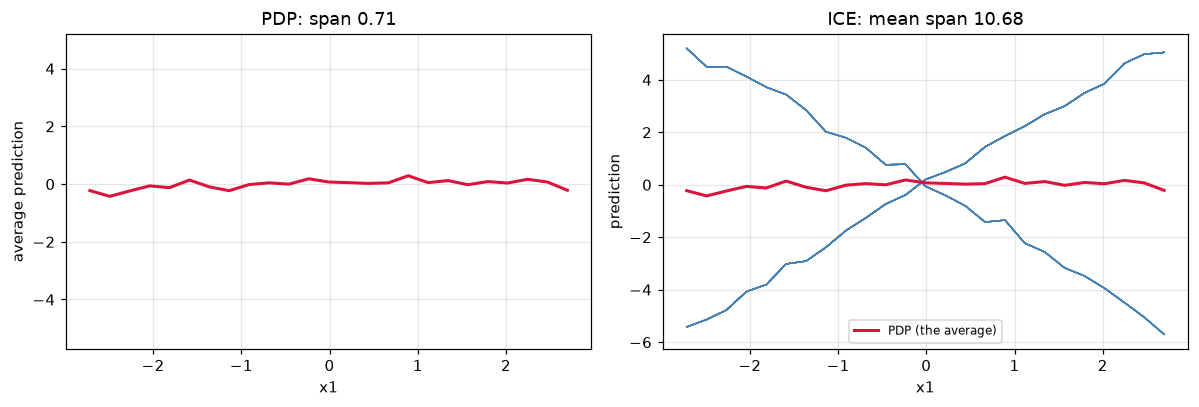

PDP span                  : 0.7143
mean span of an ICE curve : 10.6797
ICE curves rising         : 2043
ICE curves falling        : 1957

The PDP is nearly flat and would tell you x1 does not matter. It is one of the two
most important features in the data.

ALWAYS plot ICE alongside PDP. A flat PDP means either 'no effect' or 'effects that
cancel', and only the ICE curves distinguish those. sklearn does it in one argument:
PartialDependenceDisplay.from_estimator(..., kind='both').


In [8]:
# A feature whose effect is strong and OPPOSITE in two subgroups.
n2 = 4000
x1 = rng.uniform(-3, 3, n2)
grp = rng.integers(0, 2, n2)
y_int = np.where(grp == 1, 2.0 * x1, -2.0 * x1) + rng.normal(0, 0.3, n2)
X_int = pd.DataFrame({"x1": x1, "group": grp.astype(float)})
m_int = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(X_int, y_int)

print("truth: y = +2*x1 for group 1, -2*x1 for group 0.")
print("x1 has a large effect on everyone, and NO average effect.\n")

res = partial_dependence(m_int, X_int, features=["x1"], kind="both", grid_resolution=25)
avg, ice, grid = res["average"][0], res["individual"][0], res["grid_values"][0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(grid, avg, color="crimson", lw=2)
axes[0].set(xlabel="x1", ylabel="average prediction",
            title=f"PDP: span {avg.max()-avg.min():.2f}")
axes[0].set_ylim(ice.min(), ice.max())
for row in ice[::40]:
    axes[1].plot(grid, row, color="steelblue", alpha=0.25, lw=0.8)
axes[1].plot(grid, avg, color="crimson", lw=2, label="PDP (the average)")
axes[1].set(xlabel="x1", ylabel="prediction",
            title=f"ICE: mean span {np.mean(ice.max(axis=1)-ice.min(axis=1)):.2f}")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

slopes = ice[:, -1] - ice[:, 0]
print(f"PDP span                  : {avg.max() - avg.min():.4f}")
print(f"mean span of an ICE curve : {np.mean(ice.max(axis=1) - ice.min(axis=1)):.4f}")
print(f"ICE curves rising         : {(slopes > 0).sum()}")
print(f"ICE curves falling        : {(slopes < 0).sum()}")
print()
print("The PDP is nearly flat and would tell you x1 does not matter. It is one of the two")
print("most important features in the data.")
print()
print("ALWAYS plot ICE alongside PDP. A flat PDP means either 'no effect' or 'effects that")
print("cancel', and only the ICE curves distinguish those. sklearn does it in one argument:")
print("PartialDependenceDisplay.from_estimator(..., kind='both').")

In [9]:
# The second PDP problem: with correlated features it evaluates impossible rows.
h = rng.normal(170, 10, n2)                          # height, cm
w = 0.9 * (h - 170) + 70 + rng.normal(0, 4, n2)      # weight, kg - tied to height
t = 0.05 * h + 0.02 * w + rng.normal(0, 0.5, n2)
X_hw = pd.DataFrame({"height": h, "weight": w})
m_hw = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE,
                             n_jobs=-1).fit(X_hw, t)

print(f"correlation between height and weight: {np.corrcoef(h, w)[0, 1]:.3f}\n")
print("A PDP for height sweeps height while holding weight at its OBSERVED values.")
print("So it asks the model about combinations that do not exist:\n")
print(f"  {'height':>8} {'weight of real people that tall':>34} {'weights the PDP uses':>22}")
print("  " + "-" * 68)
for hh in np.percentile(h, [1, 25, 50, 75, 99]):
    near = np.abs(h - hh) < 2
    print(f"  {hh:>8.0f} {f'{w[near].min():.0f} - {w[near].max():.0f} kg':>34} "
          f"{f'{w.min():.0f} - {w.max():.0f} kg':>22}")

print()
print("At the 99th-percentile height the PDP still averages over people weighing 29 kg.")
print("The model never saw such a person, so its prediction there is extrapolation - and the")
print("PDP presents that extrapolation as if it were a measured effect.")
print()
print("This is the same objection as SHAP's independence assumption (3.2), and there is no")
print("fully satisfying fix. Accumulated Local Effects (ALE) plots address it by averaging")
print("over a LOCAL window of realistic values instead.")

correlation between height and weight: 0.913

A PDP for height sweeps height while holding weight at its OBSERVED values.
So it asks the model about combinations that do not exist:

    height    weight of real people that tall   weights the PDP uses
  --------------------------------------------------------------------
       147                         42 - 57 kg            34 - 107 kg
       163                         52 - 76 kg            34 - 107 kg
       170                         58 - 84 kg            34 - 107 kg
       177                         62 - 91 kg            34 - 107 kg
       195                        83 - 100 kg            34 - 107 kg

At the 99th-percentile height the PDP still averages over people weighing 29 kg.
The model never saw such a person, so its prediction there is extrapolation - and the
PDP presents that extrapolation as if it were a measured effect.

This is the same objection as SHAP's independence assumption (3.2), and there is no
fully satisfyin

## 1.6 SHAP

SHAP treats a prediction as a **cooperative game**: the features are players, the prediction is
the payout, and the question is how to divide the payout fairly. The **Shapley value** (Shapley,
1953) is the unique allocation satisfying four axioms — efficiency, symmetry, dummy and
additivity — and it is the average marginal contribution of a feature across all possible
orderings of the players.

The consequence you can check directly is **efficiency**, usually called additivity here:

$$ f(x) = \mathbb{E}[f(X)] + \sum_{j} \phi_j(x) $$

The base value plus the feature attributions equals the prediction **exactly**, for every row.

In [10]:
explainer = shap.TreeExplainer(rf)
X_explain = X_test.iloc[:400]
shap_values = np.asarray(explainer.shap_values(X_explain))
base_value = float(np.ravel(explainer.expected_value)[0])

print(f"shap_values shape : {shap_values.shape}   (rows x features)")
print(f"base value        : {base_value:.6f}")
print(f"mean training prediction : {rf.predict(X_train).mean():.6f}\n")

reconstructed = base_value + shap_values.sum(axis=1)
actual = rf.predict(X_explain)
print("ADDITIVITY CHECK: base value + sum of SHAP values == prediction?")
print(f"  max |difference|  : {np.abs(reconstructed - actual).max():.3e}")
print(f"  mean |difference| : {np.abs(reconstructed - actual).mean():.3e}")
print()
print("That is exact to floating-point precision, and it is the property that makes SHAP")
print("different in kind from the other methods. A SHAP explanation is not an approximation")
print("of the prediction - it is a complete decomposition of it.")
print()

# One prediction, explained.
i = 0
row = X_explain.iloc[i]
contrib = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
print(f"Explaining row {i}: the model predicts {actual[i]:.4f} "
      f"(average is {base_value:.4f})\n")
print(f"  {'feature':<12} {'value':>10} {'SHAP':>10}  effect")
print("  " + "-" * 52)
for f, v in contrib.items():
    arrow = "pushes UP  " if v > 0 else "pushes DOWN"
    print(f"  {f:<12} {row[f]:>10.3f} {v:>10.4f}  {arrow}")
print(f"  {'':<12} {'':>10} {'':>10}")
print(f"  base {base_value:.4f} + contributions {contrib.sum():+.4f} = {actual[i]:.4f}")

shap_values shape : (400, 8)   (rows x features)
base value        : 2.070711
mean training prediction : 2.071568

ADDITIVITY CHECK: base value + sum of SHAP values == prediction?
  max |difference|  : 5.507e-14
  mean |difference| : 8.768e-15

That is exact to floating-point precision, and it is the property that makes SHAP
different in kind from the other methods. A SHAP explanation is not an approximation
of the prediction - it is a complete decomposition of it.

Explaining row 0: the model predicts 0.5408 (average is 2.0707)

  feature           value       SHAP  effect
  ----------------------------------------------------
  MedInc            1.681    -0.8247  pushes DOWN
  Latitude         36.060    -0.2885  pushes DOWN
  AveOccup          3.877    -0.2441  pushes DOWN
  Longitude      -119.010    -0.1605  pushes DOWN
  AveBedrms         1.022    -0.0090  pushes DOWN
  AveRooms          4.192    -0.0033  pushes DOWN
  HouseAge         25.000     0.0012  pushes UP  
  Population  

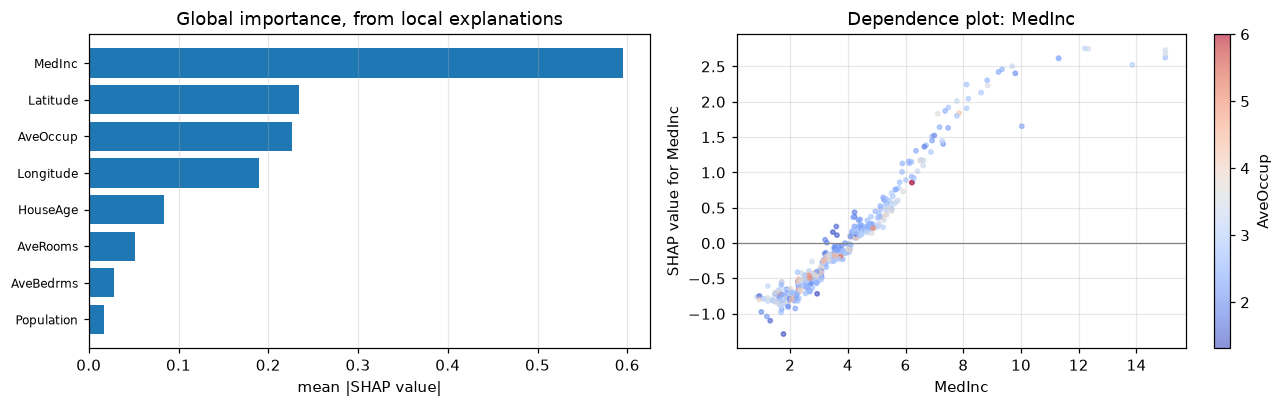

mean |SHAP| ranking:
  MedInc       0.5956
  Latitude     0.2348
  AveOccup     0.2266
  Longitude    0.1900
  HouseAge     0.0842
  AveRooms     0.0511
  AveBedrms    0.0279
  Population   0.0167

Two distinct outputs from one computation:
  LEFT  - averaging |SHAP| over rows gives a global importance ranking.
  RIGHT - a dependence plot shows how one feature's CONTRIBUTION varies with its
          value, and the colour reveals interaction with a second feature.

The dependence plot is the more useful of the two and the more neglected. A bar chart
says 'MedInc matters'; the dependence plot says how, and where it stops mattering.

Cost note: TreeExplainer is exact and fast for tree models. For arbitrary models,
KernelExplainer approximates Shapley values by sampling and is orders of magnitude
slower - which is why SHAP is used far more with trees than with anything else.


In [11]:
# Global importance by aggregating local explanations.
shap_global = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
order = shap_global.sort_values().index
axes[0].barh(range(len(order)), shap_global[order])
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order, fontsize=8)
axes[0].set(xlabel="mean |SHAP value|", title="Global importance, from local explanations")
axes[0].grid(alpha=0.3, axis="x")

top_feat = shap_global.idxmax()
j = FEATURES.index(top_feat)
sc = axes[1].scatter(X_explain[top_feat], shap_values[:, j], s=8, alpha=0.6,
                     c=X_explain["AveOccup"].clip(upper=6), cmap="coolwarm")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set(xlabel=top_feat, ylabel=f"SHAP value for {top_feat}",
            title=f"Dependence plot: {top_feat}")
plt.colorbar(sc, ax=axes[1], label="AveOccup")
axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

print(f"mean |SHAP| ranking:")
for f, v in shap_global.sort_values(ascending=False).items():
    print(f"  {f:<12} {v:.4f}")
print()
print("Two distinct outputs from one computation:")
print("  LEFT  - averaging |SHAP| over rows gives a global importance ranking.")
print("  RIGHT - a dependence plot shows how one feature's CONTRIBUTION varies with its")
print("          value, and the colour reveals interaction with a second feature.")
print()
print("The dependence plot is the more useful of the two and the more neglected. A bar chart")
print("says 'MedInc matters'; the dependence plot says how, and where it stops mattering.")
print()
print("Cost note: TreeExplainer is exact and fast for tree models. For arbitrary models,")
print("KernelExplainer approximates Shapley values by sampling and is orders of magnitude")
print("slower - which is why SHAP is used far more with trees than with anything else.")

## 1.7 LIME

**Local Interpretable Model-agnostic Explanations** (Ribeiro et al., 2016). To explain one
prediction: sample points near it, label them with the black box, fit a **weighted linear
model** to those labels, and report its coefficients.

The appeal is that it works on anything. The weakness is in "sample points near it" — the
result depends on the sampling, and therefore on the random seed.

In [12]:
lime_expl_maker = lambda seed: LimeTabularExplainer(
    X_train.to_numpy(), feature_names=FEATURES, mode="regression", random_state=seed)

instance = X_test.to_numpy()[0]
runs = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")            # lime is chatty about its internals
    for seed in range(10):
        e = lime_expl_maker(seed)
        exp = e.explain_instance(instance, rf.predict, num_features=len(FEATURES),
                                 num_samples=1000)
        d = dict(exp.as_map()[0])
        runs.append([d.get(k, 0.0) for k in range(len(FEATURES))])

R = pd.DataFrame(runs, columns=FEATURES)
ranks = R.abs().rank(axis=1, ascending=False)
summary = pd.DataFrame({
    "mean weight": R.mean(),
    "std": R.std(),
    "best rank": ranks.min().astype(int),
    "worst rank": ranks.max().astype(int),
}).sort_values("mean weight", key=np.abs, ascending=False)

print("The SAME prediction explained 10 times, varying only the random seed:\n")
print(summary.round(4).to_string())
print(f"\ntop feature chosen in each of the 10 runs: "
      f"{R.abs().idxmax(axis=1).value_counts().to_dict()}")
print()
print("Be precise about what this shows, because 'LIME is unstable' is too broad.")
print()
print("  The TOP feature is perfectly stable - MedInc wins all 10 runs.")
print("  The TAIL is noise: five features swing between rank 4 and rank 8 across runs, and")
print("  for several the standard deviation exceeds the mean.")
print()
print("So a LIME explanation's headline is trustworthy and its ordering below the top one or")
print("two is not. If you show a user 'the five reasons', four of them may be different")
print("tomorrow.")
print()
print("Mitigations: raise num_samples (slower, less variance), fix random_state (hides the")
print("problem rather than fixing it), or run it several times and report only features that")
print("are stable - which is really an admission that one run is not enough.")

The SAME prediction explained 10 times, varying only the random seed:

            mean weight     std  best rank  worst rank
MedInc           0.8393  0.0677          1           1
AveOccup         0.3278  0.0595          2           3
Latitude         0.2554  0.0577          2           3
Longitude       -0.1197  0.0498          4           8
AveBedrms        0.0741  0.0828          4           8
AveRooms         0.0661  0.0714          4           8
Population       0.0276  0.0642          4           8
HouseAge         0.0164  0.0764          4           8

top feature chosen in each of the 10 runs: {'MedInc': 10}

Be precise about what this shows, because 'LIME is unstable' is too broad.

  The TOP feature is perfectly stable - MedInc wins all 10 runs.
  The TAIL is noise: five features swing between rank 4 and rank 8 across runs, and
  for several the standard deviation exceeds the mean.

So a LIME explanation's headline is trustworthy and its ordering below the top one or
two is 

## 1.8 Importance is not causation

The most consequential misreading in this whole notebook. Feature importance tells you what the
**model uses**. Whether the feature *causes* the outcome is a question about the world, and no
amount of model inspection answers it.

The clean demonstration is the **omitted variable**: what happens when the true cause is not in
your dataset.

In [13]:
n3 = 5000
rain = rng.normal(size=n3)                          # the true cause
umbrella = 0.9 * rain + rng.normal(0, 0.4, n3)      # caused BY rain; causes nothing
wet = 2.0 * rain + rng.normal(0, 0.3, n3)           # caused by rain ONLY

print("Ground truth:  rain --> wet pavement")
print("               rain --> umbrella sales")
print("               umbrella sales have NO effect on the pavement.\n")

for label, cols in [("both features available", ["rain", "umbrella_sales"]),
                    ("the true cause is MISSING", ["umbrella_sales"])]:
    frame = pd.DataFrame({"rain": rain, "umbrella_sales": umbrella})[cols]
    m = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(frame, wet)
    p = permutation_importance(m, frame, wet, n_repeats=8, random_state=RANDOM_STATE,
                               n_jobs=-1)
    cv = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE,
                                               n_jobs=-1), frame, wet, cv=5).mean()
    print(f"  {label:<28} cross-validated R2 {cv:.4f}")
    for c, v in zip(cols, p.importances_mean):
        print(f"      permutation importance of {c:<16} {v:.4f}")
    print()

print("Read the two blocks together.")
print()
print("With rain present, umbrella sales are correctly judged near-useless.")
print()
print("Remove rain - and you are ALWAYS in this situation, since no dataset contains every")
print("cause - and umbrella sales become the single most important feature, in a model with")
print("a perfectly respectable R2. Nothing in the output hints that it is a proxy.")
print()
print("This is NB-01 Q10's omitted-variable argument, arriving through a different door.")
print()
print("What follows practically:")
print("  - 'Feature X is important' NEVER licenses 'changing X will change the outcome'.")
print("  - An importance ranking is a description of a model, not a list of interventions.")
print("  - If someone will ACT on the explanation, you need causal inference - a randomised")
print("    experiment, or a causal model with stated assumptions - not a SHAP plot.")
print()
print("The honest sentence is: 'the model relies heavily on X', never 'X drives the outcome'.")

Ground truth:  rain --> wet pavement
               rain --> umbrella sales
               umbrella sales have NO effect on the pavement.

  both features available      cross-validated R2 0.9737
      permutation importance of rain             1.9908
      permutation importance of umbrella_sales   0.0171

  the true cause is MISSING    cross-validated R2 0.7416
      permutation importance of umbrella_sales   1.8931

Read the two blocks together.

With rain present, umbrella sales are correctly judged near-useless.

Remove rain - and you are ALWAYS in this situation, since no dataset contains every
cause - and umbrella sales become the single most important feature, in a model with
a perfectly respectable R2. Nothing in the output hints that it is a proxy.

This is NB-01 Q10's omitted-variable argument, arriving through a different door.

What follows practically:
  - 'Feature X is important' NEVER licenses 'changing X will change the outcome'.
  - An importance ranking is a descript

***
# Part 2 - Worked example: explaining a house-price model

**The task.** A 120-tree random forest predicting median house value in California districts
from eight features. It scores R² ≈ 0.80 and has roughly 100,000 decision nodes. Explain it.

**Why this dataset.** The features are interpretable enough that you can sanity-check any
answer against intuition, and correlated enough that §2.3's disagreement is real rather than
constructed.

## 2.1 Global: what does the model use?

In [14]:
# MDI comes free with a fitted tree ensemble.
mdi = pd.Series(rf.feature_importances_, index=FEATURES)

perm_te = permutation_importance(rf, X_test.iloc[:2000], y_test.iloc[:2000],
                                 n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm_te.importances_mean, index=FEATURES)

shap_s = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)

glob = pd.DataFrame({"MDI": mdi, "permutation": perm_s, "mean|SHAP|": shap_s})
print("three global methods, all computed on the SAME fitted model:\n")
print(glob.sort_values("permutation", ascending=False).round(4).to_string())

print("\nrank correlations:")
for i, aa in enumerate(glob.columns):
    for bb in glob.columns[i + 1:]:
        print(f"  {aa:<12} vs {bb:<12} {spearmanr(glob[aa], glob[bb]).statistic:.4f}")

print()
print("These three broadly agree, which is the common case and the reason people trust them.")
print("MedInc (median income) dominates, then the geographic features. That is plausible:")
print("California house prices are mostly income and location.")
print()
print("MDI is free but has a known bias toward high-cardinality and continuous features")
print("(NB-04), and it is computed on TRAINING impurity, so it cannot see overfitting.")
print("Prefer permutation or SHAP when you have the compute.")

three global methods, all computed on the SAME fitted model:

               MDI  permutation  mean|SHAP|
MedInc      0.5562       0.7802      0.5956
Latitude    0.0840       0.3741      0.2348
Longitude   0.0837       0.2907      0.1900
AveOccup    0.1400       0.2037      0.2266
HouseAge    0.0505       0.0684      0.0842
AveRooms    0.0379       0.0235      0.0511
Population  0.0242       0.0098      0.0167
AveBedrms   0.0235       0.0074      0.0279

rank correlations:
  MDI          vs permutation  0.9286
  MDI          vs mean|SHAP|   0.9524
  permutation  vs mean|SHAP|   0.9524

These three broadly agree, which is the common case and the reason people trust them.
MedInc (median income) dominates, then the geographic features. That is plausible:
California house prices are mostly income and location.

MDI is free but has a known bias toward high-cardinality and continuous features
(NB-04), and it is computed on TRAINING impurity, so it cannot see overfitting.
Prefer permutation o

## 2.2 Local: why this house?

In [15]:
# Pick an unusual prediction to explain - extremes are where explanations earn their keep.
preds = rf.predict(X_explain)
idx_high = int(np.argmax(preds))
idx_low = int(np.argmin(preds))

for label, i in [("HIGHEST predicted value", idx_high), ("LOWEST predicted value", idx_low)]:
    row = X_explain.iloc[i]
    contrib = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs,
                                                                    ascending=False)
    print(f"{label}: model predicts {preds[i]:.4f} (average {base_value:.4f})")
    print(f"  {'feature':<12} {'this row':>12} {'dataset median':>16} {'SHAP':>10}")
    print("  " + "-" * 56)
    for f, v in contrib.items():
        print(f"  {f:<12} {row[f]:>12.3f} {X[f].median():>16.3f} {v:>10.4f}")
    print(f"  -> base {base_value:.3f} {contrib.sum():+.3f} = {preds[i]:.3f}\n")

print("Showing the row's value beside the dataset median is what makes a SHAP table")
print("readable. 'MedInc contributed +1.2' means nothing on its own; 'MedInc is 8.3 against")
print("a median of 3.5, contributing +1.2' is an explanation a person can check.")

HIGHEST predicted value: model predicts 4.9996 (average 2.0707)
  feature          this row   dataset median       SHAP
  --------------------------------------------------------
  MedInc             15.000            3.535     2.6252
  Longitude        -122.220         -118.490     0.1849
  HouseAge           32.000           29.000     0.0542
  AveRooms            8.845            5.229     0.0297
  Latitude           37.440           34.260     0.0254
  Population       1318.000         1166.000     0.0198
  AveOccup            2.723            2.818    -0.0103
  AveBedrms           1.035            1.049     0.0001
  -> base 2.071 +2.929 = 5.000

LOWEST predicted value: model predicts 0.5315 (average 2.0707)
  feature          this row   dataset median       SHAP
  --------------------------------------------------------
  MedInc              1.458            3.535    -0.8253
  Latitude           36.710           34.260    -0.3179
  AveOccup            4.148            2.818    -0.

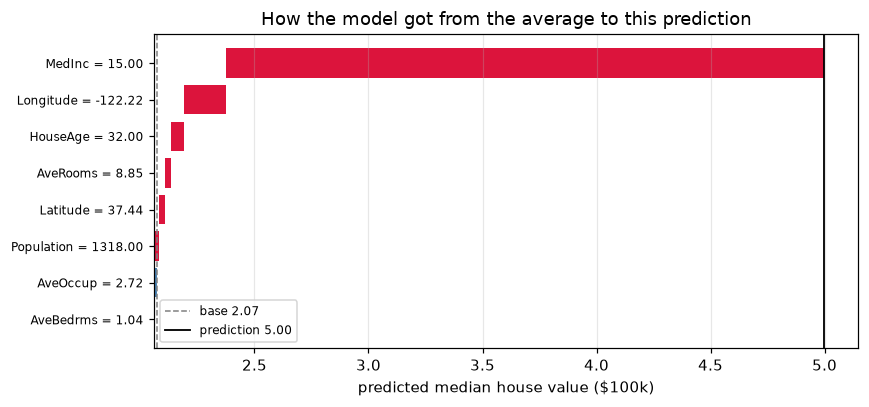

Read it left to right: start at the average prediction, add each feature's
contribution, arrive at this row's prediction. The bars must sum exactly (1.6).

This is the chart to put in front of a non-technical stakeholder. It answers 'why
this one?' rather than 'what does the model do in general?', which is almost always
the question actually being asked.


In [16]:
# A waterfall, drawn by hand so it is clear what the library plot does.
i = idx_high
contrib = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs)
fig, ax = plt.subplots(figsize=(8, 3.8))
running = base_value
for k, (f, v) in enumerate(contrib.items()):
    ax.barh(k, v, left=running, color="crimson" if v > 0 else "steelblue")
    running += v
ax.axvline(base_value, color="gray", ls="--", lw=1, label=f"base {base_value:.2f}")
ax.axvline(running, color="black", lw=1.2, label=f"prediction {running:.2f}")
ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([f"{f} = {X_explain.iloc[i][f]:.2f}" for f in contrib.index], fontsize=8)
ax.set(xlabel="predicted median house value ($100k)",
       title="How the model got from the average to this prediction")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

print("Read it left to right: start at the average prediction, add each feature's")
print("contribution, arrive at this row's prediction. The bars must sum exactly (1.6).")
print()
print("This is the chart to put in front of a non-technical stakeholder. It answers 'why")
print("this one?' rather than 'what does the model do in general?', which is almost always")
print("the question actually being asked.")

## 2.3 Now compare five methods — and watch one disagree completely

In [17]:
# Drop-column: one refit per feature. Slower, and it answers a different question.
def small_rf():
    return RandomForestRegressor(n_estimators=120, max_depth=12,
                                 random_state=RANDOM_STATE, n_jobs=-1)


t0 = time.time()
full_score = rf.score(X_test, y_test)
drop = {}
for col in FEATURES:
    keep = [c for c in FEATURES if c != col]
    drop[col] = full_score - small_rf().fit(X_train[keep], y_train).score(X_test[keep], y_test)
drop_s = pd.Series(drop)
print(f"drop-column importance took {time.time()-t0:.1f}s ({len(FEATURES)} refits)\n")

perm_tr = permutation_importance(rf, X_train.iloc[:2000], y_train.iloc[:2000],
                                 n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

table = pd.DataFrame({
    "MDI": mdi,
    "perm (test)": perm_s,
    "perm (train)": pd.Series(perm_tr.importances_mean, index=FEATURES),
    "mean|SHAP|": shap_s,
    "drop-column": drop_s,
})
print("RANKS (1 = most important):\n")
ranks = table.rank(ascending=False).astype(int)
print(ranks.to_string())

print("\npairwise Spearman correlation between the rankings:\n")
cols = list(table.columns)
print("              " + "".join(f"{c[:12]:>14}" for c in cols))
for aa in cols:
    print(f"{aa:<14}" + "".join(
        f"{spearmanr(table[aa], table[bb]).statistic:>14.3f}" for bb in cols))

print("\ntop-ranked feature by each method:")
for c in cols:
    print(f"  {c:<14} {table[c].idxmax()}")

drop-column importance took 20.1s (8 refits)

RANKS (1 = most important):

            MDI  perm (test)  perm (train)  mean|SHAP|  drop-column
MedInc        1            1             1           1            8
HouseAge      5            5             5           5            7
AveRooms      6            6             6           6            6
AveBedrms     8            8             7           7            5
Population    7            7             8           8            4
AveOccup      2            4             4           3            3
Latitude      3            2             2           2            1
Longitude     4            3             3           4            2

pairwise Spearman correlation between the rankings:

                         MDI   perm (test)  perm (train)    mean|SHAP|   drop-column
MDI                    1.000         0.929         0.905         0.952         0.048
perm (test)            0.929         1.000         0.976         0.952         0.119
perm

In [18]:
print("Four of the five methods agree closely. Drop-column is almost uncorrelated with all")
print("of them, and it ranks MedInc - everyone else's clear winner - LAST.\n")
print("That is not a bug. Follow it through:\n")

keep = [c for c in FEATURES if c != "MedInc"]
without = small_rf().fit(X_train[keep], y_train)
print(f"  full model R2                        : {full_score:.4f}")
print(f"  R2 after removing MedInc and refitting: {without.score(X_test[keep], y_test):.4f}")
print(f"  loss                                  : {full_score - without.score(X_test[keep], y_test):+.4f}")
print(f"  permutation importance of MedInc      : {perm_s['MedInc']:.4f} "
      f"(rank {int(ranks.loc['MedInc', 'perm (test)'])})")

recover = small_rf().fit(X_train[keep], X_train["MedInc"])
print(f"\n  R2 predicting MedInc from the other 7 features: "
      f"{recover.score(X_test[keep], X_test['MedInc']):.4f}")
print("\n  largest pairwise correlation of MedInc with any single other feature: "
      f"{max(abs(np.corrcoef(X['MedInc'], X[c])[0,1]) for c in keep):.3f}")

print()
print("So: scrambling MedInc destroys the model, but REMOVING it costs almost nothing,")
print("because the other seven features jointly reconstruct it.")
print()
print("Note the last line carefully. No single feature correlates strongly with MedInc - the")
print("largest is about 0.33. The redundancy is MULTIVARIATE, and a correlation matrix would")
print("not have warned you. This is why 'I checked for correlated features' is not a defence.")
print()
print("The two families answer genuinely different questions:")
print()
print("  permutation / SHAP / MDI : how much does THIS FITTED MODEL rely on the feature?")
print("                             -> the right question for debugging and for describing")
print("                                the model you actually shipped.")
print()
print("  drop-column              : how much worse would a model be if this feature had")
print("                             never existed?")
print("                             -> the right question for 'should we keep paying to")
print("                                collect this?'")
print()
print("Neither is more correct. Reporting one while the audience assumes the other is how")
print("explanation goes wrong in practice.")

Four of the five methods agree closely. Drop-column is almost uncorrelated with all
of them, and it ranks MedInc - everyone else's clear winner - LAST.

That is not a bug. Follow it through:

  full model R2                        : 0.7957
  R2 after removing MedInc and refitting: 0.8088
  loss                                  : -0.0130
  permutation importance of MedInc      : 0.7802 (rank 1)

  R2 predicting MedInc from the other 7 features: 0.7826

  largest pairwise correlation of MedInc with any single other feature: 0.327

So: scrambling MedInc destroys the model, but REMOVING it costs almost nothing,
because the other seven features jointly reconstruct it.

Note the last line carefully. No single feature correlates strongly with MedInc - the
largest is about 0.33. The redundancy is MULTIVARIATE, and a correlation matrix would
not have warned you. This is why 'I checked for correlated features' is not a defence.

The two families answer genuinely different questions:

  permutati

***
# Part 3 - The uncomfortable parts

Four things that are true about explanation methods and rarely said in the same place.

## 3.1 When methods disagree, decide which question you asked

§2.3 produced a 0.05 rank correlation between two respectable methods. That is not a reason to
distrust both — it is a signal that the word "importance" was doing too much work.

A checklist for reconciling a disagreement:

In [19]:
print("A disagreement diagnostic you can run in five lines.\n")
disagreement = pd.DataFrame(index=FEATURES)
disagreement["perm rank"] = table["perm (test)"].rank(ascending=False)
disagreement["drop rank"] = table["drop-column"].rank(ascending=False)
disagreement["gap"] = (disagreement["perm rank"] - disagreement["drop rank"]).abs()
disagreement["recoverable R2"] = [
    small_rf().fit(X_train[[c for c in FEATURES if c != f]], X_train[f])
    .score(X_test[[c for c in FEATURES if c != f]], X_test[f])
    for f in FEATURES
]
print(disagreement.sort_values("gap", ascending=False).round(3).to_string())

print()
print("The 'recoverable R2' column is how well the OTHER features predict this one.")
print()
print("For MedInc it settles the argument immediately: 78% recoverable, so permutation ranks")
print("it 1st (the fitted model leans on it) and drop-column ranks it 8th (a refit model does")
print("not need it). That is the whole disagreement, explained.")
print()
print(f"But do NOT over-generalise: across all 8 features the rank correlation between the")
print(f"gap and recoverability is "
      f"{spearmanr(disagreement['gap'], disagreement['recoverable R2']).statistic:+.3f} -")
print("weak, and the wrong sign for a tidy rule. Latitude is 95% recoverable with a rank gap")
print("of only 1.")
print()
print("So recoverability is a DIAGNOSTIC to run on a specific disagreement, not a predictor")
print("of which features will disagree. Eight features is also far too few to fit a trend to,")
print("and reporting one from this table would be exactly the over-reading this notebook")
print("keeps warning about.")
print()
print("(AveOccup's negative R2 is not a bug: a model can predict a feature WORSE than its own")
print("mean, and that is what a negative R2 means. It is simply not recoverable at all.)")
print()
print("When two methods disagree, ask in order:")
print("  1. Do they hold the same things fixed? (permutation shuffles one column; drop-column")
print("     removes it and lets the model re-learn.)")
print("  2. Does one refit and the other not? A refit model is a DIFFERENT model.")
print("  3. Are the disagreeing features reconstructable from the others? Compute the column")
print("     above - it usually settles it.")
print("  4. Is the difference larger than the methods' own noise? Permutation importance has")
print("     a standard deviation; LIME has a seed (1.7).")

A disagreement diagnostic you can run in five lines.

            perm rank  drop rank  gap  recoverable R2
MedInc            1.0        8.0  7.0           0.783
AveBedrms         8.0        5.0  3.0           0.818
Population        7.0        4.0  3.0           0.279
HouseAge          5.0        7.0  2.0           0.555
Latitude          2.0        1.0  1.0           0.955
AveOccup          4.0        3.0  1.0          -6.003
Longitude         3.0        2.0  1.0           0.952
AveRooms          6.0        6.0  0.0           0.902

The 'recoverable R2' column is how well the OTHER features predict this one.

For MedInc it settles the argument immediately: 78% recoverable, so permutation ranks
it 1st (the fitted model leans on it) and drop-column ranks it 8th (a refit model does
not need it). That is the whole disagreement, explained.

But do NOT over-generalise: across all 8 features the rank correlation between the
gap and recoverability is -0.381 -
weak, and the wrong sign for a t

## 3.2 Correlated features break SHAP too — but not in the way they break permutation

§1.3 showed permutation importance collapsing when a feature is duplicated. SHAP is often
presented as immune because of its axioms. It is not immune, but it fails differently, and the
difference is worth knowing.

In [20]:
print("The same duplication experiment from 1.3, now measured with SHAP.\n")
print("truth: y = 3*a + 1.5*b + 0.3*noise\n")
print(f"{'features given to the model':<30} {'mean|SHAP|'}")
print("-" * 92)
rows_summary = []
for label, frame in [
    ("a, b, noise", pd.DataFrame({"a": a, "b": b, "noise": noise})),
    ("+ one copy of a", pd.DataFrame({"a": a, "b": b, "noise": noise, "a_copy": a})),
    ("+ three copies of a",
     pd.DataFrame({"a": a, "b": b, "noise": noise, "a1": a, "a2": a, "a3": a})),
]:
    m = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(frame, y_syn)
    sv = np.abs(np.asarray(shap.TreeExplainer(m).shap_values(frame.iloc[:500]))).mean(axis=0)
    s = pd.Series(sv, index=frame.columns).sort_values(ascending=False)
    a_tot = sum(v for k, v in s.items() if k.startswith("a"))
    rows_summary.append((label, a_tot, s["b"], s[[k for k in s.index
                                                  if k.startswith("a")]].max()))
    print(f"{label:<30} " + "  ".join(f"{k}={v:.3f}" for k, v in s.items()))
    print(f"{'':<30} total for 'a' columns: {a_tot:.3f}   b: {s['b']:.3f}")

print()
print(f"{'setup':<30} {'total for a':>12} {'b':>8} {'largest single a':>18}")
print("-" * 72)
for label, tot, bb, mx in rows_summary:
    print(f"{label:<30} {tot:>12.3f} {bb:>8.3f} {mx:>18.3f}")

print()
print("Compare against 1.3's permutation numbers (1.514 -> 0.801 -> 0.393).")
print()
print("SHAP behaves BETTER: the TOTAL attributed to 'a' stays near-constant, because the")
print("efficiency axiom forces the attributions to sum to the prediction, and the model's")
print("prediction has not changed. Permutation importance has no such constraint, so its")
print("total simply evaporates.")
print()
print("But look at the last column. Each individual copy of 'a' is now smaller than 'b', so")
print("a mean|SHAP| BAR CHART - the standard output everyone shows - still ranks b above")
print("every a. The axioms guarantee a fair split among the players; they do not decide that")
print("duplicated columns are one player.")
print()
print("So the practical advice is the same for both methods:")
print("  - Cluster correlated features and report importance per GROUP, not per column.")
print("  - Or drop redundant columns before explaining (they rarely help the model either).")
print("  - And never read a small individual importance as 'this feature does not matter'.")

The same duplication experiment from 1.3, now measured with SHAP.

truth: y = 3*a + 1.5*b + 0.3*noise

features given to the model    mean|SHAP|
--------------------------------------------------------------------------------------------
a, b, noise                    a=2.294  b=1.151  noise=0.164
                               total for 'a' columns: 2.294   b: 1.151
+ one copy of a                a=1.275  b=1.151  a_copy=1.022  noise=0.164
                               total for 'a' columns: 2.297   b: 1.151
+ three copies of a            b=1.150  a2=0.626  a=0.593  a3=0.542  a1=0.540  noise=0.164
                               total for 'a' columns: 2.301   b: 1.150

setup                           total for a        b   largest single a
------------------------------------------------------------------------
a, b, noise                           2.294    1.151              2.294
+ one copy of a                       2.297    1.151              1.275
+ three copies of a             

## 3.3 Surrogate models

A different strategy: fit a simple, readable model to the **black box's predictions** rather
than to the data, and read the simple model instead. The question is **fidelity** — how well the
surrogate reproduces the original — and it trades directly against readability.

surrogate                         fidelity (R2 vs forest)    R2 vs the TRUTH
------------------------------------------------------------------------------
linear regression                                  0.7519             0.5886
decision tree, depth 2                             0.5862             0.4313
decision tree, depth 3                             0.6986             0.5164
decision tree, depth 6                             0.8510             0.6320
decision tree, depth 10                            0.9241             0.7195


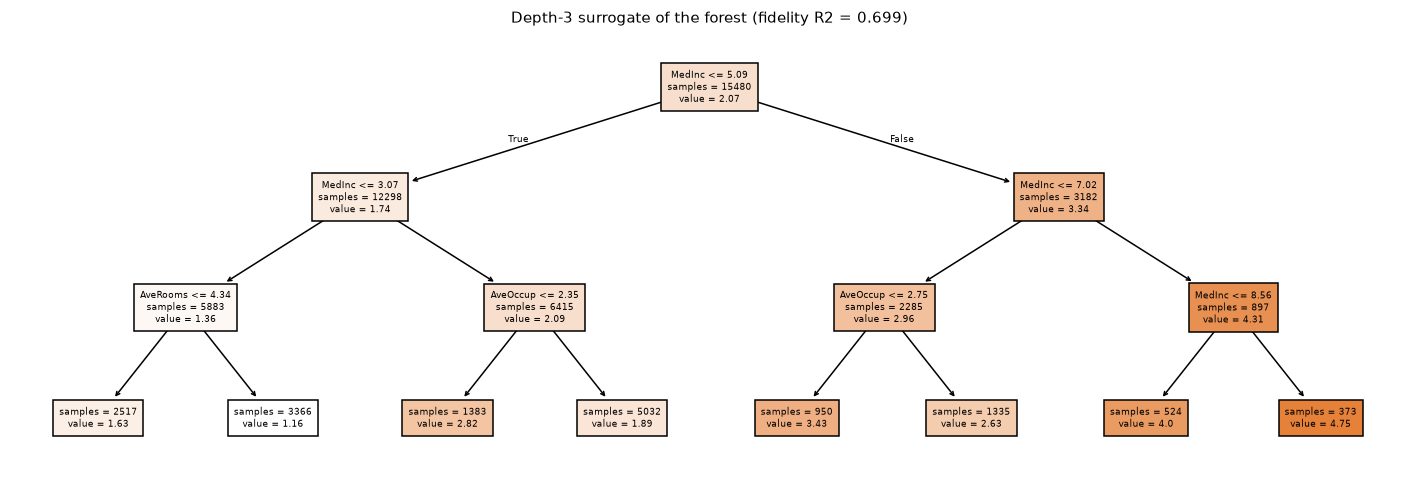


The depth-3 tree above is genuinely readable and reproduces about 70% of the forest's
variance. Whether that is 'an explanation' depends entirely on what you do with it.

It is fair to say: 'broadly, the forest splits on income first, then location'.
It is NOT fair to say: 'the forest predicted 3.2 for this house BECAUSE MedInc > 5'.
The surrogate disagrees with the forest on roughly a third of the variance, and you
do not know whether this row is in the agreeing third.

ALWAYS report fidelity beside a surrogate. A surrogate without a fidelity number is
an unfalsifiable story about a model.


In [21]:
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

print(f"{'surrogate':<32} {'fidelity (R2 vs forest)':>24} {'R2 vs the TRUTH':>18}")
print("-" * 78)
for name, sm in [
    ("linear regression", make_pipeline(StandardScaler(), LinearRegression())),
    ("decision tree, depth 2", DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)),
    ("decision tree, depth 3", DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)),
    ("decision tree, depth 6", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)),
    ("decision tree, depth 10", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
]:
    sm.fit(X_train, pred_train)                     # fit to the MODEL, not to y
    print(f"{name:<32} {sm.score(X_test, pred_test):>24.4f} {sm.score(X_test, y_test):>18.4f}")

surro = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train, pred_train)
fig, ax = plt.subplots(figsize=(13, 4.5))
plot_tree(surro, feature_names=FEATURES, filled=True, fontsize=6, ax=ax,
          impurity=False, precision=2)
ax.set_title(f"Depth-3 surrogate of the forest (fidelity R2 = "
             f"{surro.score(X_test, pred_test):.3f})", fontsize=10)
fig.tight_layout(); plt.show()

print()
print("The depth-3 tree above is genuinely readable and reproduces about 70% of the forest's")
print("variance. Whether that is 'an explanation' depends entirely on what you do with it.")
print()
print("It is fair to say: 'broadly, the forest splits on income first, then location'.")
print("It is NOT fair to say: 'the forest predicted 3.2 for this house BECAUSE MedInc > 5'.")
print("The surrogate disagrees with the forest on roughly a third of the variance, and you")
print("do not know whether this row is in the agreeing third.")
print()
print("ALWAYS report fidelity beside a surrogate. A surrogate without a fidelity number is")
print("an unfalsifiable story about a model.")

## 3.4 Rudin's counterpoint: did you need the black box?

Cynthia Rudin's 2019 paper argues that the whole enterprise is often misdirected: for
structured, meaningful features, an inherently interpretable model usually matches the black
box, so explaining a black box is solving a problem you created.

It is easy to check, and the check is rarely run.

In [22]:
Xb, yb = load_breast_cancer(return_X_y=True, as_frame=True)
print(f"breast cancer: {Xb.shape[0]} samples, {Xb.shape[1]} features\n")
print(f"{'model':<44} {'CV accuracy':>12}  interpretable?")
print("-" * 78)
for name, m, interp in [
    ("logistic regression (scaled)",
     make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
     "yes - 30 coefficients"),
    ("decision tree, depth 3",
     DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), "yes - 7 rules"),
    ("decision tree, depth 5",
     DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), "yes - ~30 rules"),
    ("random forest, 300 trees",
     RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
     "NO - needs SHAP"),
]:
    print(f"{name:<44} {cross_val_score(m, Xb, yb, cv=5).mean():>12.4f}  {interp}")

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xb, yb)
coefs = pd.Series(lr[-1].coef_[0], index=Xb.columns).sort_values(key=np.abs,
                                                                 ascending=False)
print("\nthe interpretable model's five largest coefficients (standardised):")
for f, v in coefs.head(5).items():
    print(f"  {f:<28} {v:+.3f}   {'increases' if v > 0 else 'decreases'} P(benign)")

print()
print("Logistic regression BEATS the 300-tree forest here, and its explanation is not an")
print("approximation of anything - the coefficients ARE the model.")
print()
print("Rudin's argument in one line: if the interpretable model is as accurate, every hour")
print("spent explaining the black box was spent solving a problem you created.")
print()
print("The argument does not always win. Where it is weakest:")
print("  - Unstructured data (images, audio, raw text), where features are pixels and there")
print("    is nothing to interpret in the input space.")
print("  - Genuinely large accuracy gaps - NB-05 shows boosting well ahead of linear models")
print("    on many tabular problems, and a 3-point gap in fraud detection is real money.")
print()
print("But the check costs one line of cross_val_score, and running it BEFORE reaching for")
print("SHAP is the single most useful habit in this notebook.")

breast cancer: 569 samples, 30 features

model                                         CV accuracy  interpretable?
------------------------------------------------------------------------------
logistic regression (scaled)                       0.9807  yes - 30 coefficients
decision tree, depth 3                             0.9191  yes - 7 rules
decision tree, depth 5                             0.9191  yes - ~30 rules
random forest, 300 trees                           0.9614  NO - needs SHAP

the interpretable model's five largest coefficients (standardised):
  worst texture                -1.321   decreases P(benign)
  radius error                 -1.289   decreases P(benign)
  worst radius                 -1.027   decreases P(benign)
  area error                   -0.999   decreases P(benign)
  worst area                   -0.995   decreases P(benign)

Logistic regression BEATS the 300-tree forest here, and its explanation is not an
approximation of anything - the coefficients ARE t

***
# Part 4 - Tough questions

***

### Q1. What is the difference between global and local explanation, and when do you need each?

<details><summary>Answer</summary>

**Global** describes the model overall; **local** explains one prediction. They serve different
audiences and a method built for one answers the other badly.

| | Global | Local |
|---|---|---|
| Question | what does this model do? | why *this* row? |
| Methods | permutation, drop-column, MDI, PDP/ICE | SHAP, LIME, counterfactuals |
| Audience | model reviewers, your own debugging | the affected person, support staff |

**You need global** when deciding whether to ship, hunting for leakage (a feature that is
implausibly important is the classic tell), or writing model documentation.

**You need local** whenever a decision affects an individual and someone will ask why. A loan
declined, a claim flagged, a scan escalated. "The model weights income heavily in general" does
not answer "why was *I* declined?"

**The bridge:** SHAP is local but aggregates — averaging |SHAP| across rows gives a global
ranking (§1.6). That is convenient and slightly dangerous, because the average hides exactly
the heterogeneity §1.5 shows PDPs hiding. Two features can have identical mean |SHAP| while one
matters enormously for a subgroup and not at all elsewhere.

</details>

***

### Q2. How does permutation importance work, and on train or test?

<details><summary>Answer</summary>

Shuffle one column, breaking its relationship with the target while preserving its marginal
distribution; the drop in score is the importance. Model-agnostic, needs no refit, one pass per
feature per repeat.

**Use test by default, but compute both** — the gap is informative:

| | measures |
|---|---|
| **on test** | which features drive **generalisation** |
| **on train** | which features the model **learned to rely on**, including memorisation |

A feature important on train and unimportant on test is one the model overfitted to. §1.2
computes both and the comparison is free.

**Three things people get wrong:**

1. **It is stochastic.** §1.2 reports the standard deviation across repeats; a difference
   smaller than that std is not a difference. Always use `n_repeats > 1`.
2. **It measures the fitted model, not the feature.** Nothing is refitted, so the answer is
   about this model. §2.3 shows the same feature ranking 1st by permutation and 8th by
   drop-column.
3. **Correlated features destroy it** (§1.3, Q3).

**A subtlety worth knowing:** permuting a column creates rows that may be impossible — a house
with 3 rooms and 40 occupants. The model is being scored on inputs off its training manifold.
This is the same objection as the PDP's (§1.5) and SHAP's (§3.2), and it has no clean fix.

</details>

***

### Q3. Two features are highly correlated. What happens to their importance?

<details><summary>Answer</summary>

**It splits between them, and the total can collapse.** §1.3 measures it on data where the
truth is known — `y = 3a + 1.5b + 0.3·noise`, so `a` must always outrank `b`:

| features given to the model | total importance for `a` | `b` |
|---|---|---|
| a, b, noise | **1.514** | 0.411 |
| + one copy of a | 0.801 | 0.411 |
| + three copies of a | **0.393** | **0.411** |

With three copies, `b` outranks `a` — an inversion of the truth, with the model's R² unchanged
at 0.9958. Only the explanation moved. The copy need not be exact: adding 1% noise splits the
importance almost as badly.

**Why:** shuffling one column asks "what if this were uninformative?", and with a duplicate
present the honest answer is "nothing much".

**SHAP is better but not immune** (§3.2). The efficiency axiom forces attributions to sum to
the prediction, so the **total** for `a` stays near-constant (**2.294 → 2.301**) where
permutation's evaporated. But it still splits across copies — the largest single `a` falls from
2.294 to **0.626**, below `b`'s 1.150 — so the standard mean-|SHAP| bar chart still misleads.

**What to do:**

- **Cluster correlated features and report importance per group.** `scipy`'s hierarchical
  clustering on the correlation matrix, then permute whole clusters.
- **Drop redundant columns before explaining.** They rarely help the model either.
- **Never read a small individual importance as "this feature doesn't matter."**
- And note §2.3's warning: the redundancy can be **multivariate**. MedInc correlates at most
  0.33 with any single other feature, yet the other seven reconstruct it at R² 0.78. A
  correlation matrix would not have warned you.

</details>

***

### Q4. What does a partial dependence plot show, and what can it hide?

<details><summary>Answer</summary>

It shows the average predicted outcome as one feature varies, averaging over the observed values
of the others. It hides two things, and both are serious.

**1. Heterogeneous effects cancel.** §1.5 builds a feature with a +2 effect in one group and −2
in the other:

| | span |
|---|---|
| PDP (the average) | **0.71** |
| mean ICE curve | **10.68** |

The PDP is nearly flat and would tell you the feature does not matter. It is one of the two
most important features in the data — roughly half the ICE curves rise and half fall, so the
average is close to zero while every individual effect is large.

**The fix is free:** always plot ICE alongside PDP —
`PartialDependenceDisplay.from_estimator(..., kind="both")`. A flat PDP means either "no
effect" or "effects that cancel", and only the ICE curves distinguish them.

**2. With correlated features, it evaluates impossible rows.** §1.5's second demo: height and
weight correlate at 0.91. The PDP for height sweeps height while holding weight at *all* its
observed values — so at the 99th-percentile height it still averages over people weighing 29 kg,
who do not exist. The model's prediction there is extrapolation, presented as a measured effect.

**Accumulated Local Effects (ALE)** plots address this by averaging over a *local* window of
realistic values instead. They are the better default for correlated features and much less
widely used than they should be.

</details>

***

### Q5. Explain SHAP. Why is it considered more principled than the alternatives?

<details><summary>Answer</summary>

SHAP treats a prediction as a **cooperative game**: features are players, the prediction is the
payout, and the Shapley value divides the payout by each player's average marginal contribution
across all possible orderings.

**It is the unique allocation satisfying four axioms:**

- **Efficiency** — the attributions sum to the prediction minus the base value.
- **Symmetry** — two features contributing identically get identical credit.
- **Dummy** — a feature that never changes the prediction gets zero.
- **Additivity** — attributions for a sum of models are the sum of attributions.

That uniqueness is the "principled" claim: given those axioms, there is no other answer.

**Efficiency is checkable, and §1.6 checks it:** base value + Σ SHAP = prediction to
**5.5 × 10⁻¹⁴**. A SHAP explanation is not an approximation of the prediction; it is a complete
decomposition of it. No other method here has that property.

**The costs and caveats:**

- **Exact Shapley values are exponential** in the number of features. `TreeExplainer` exploits
  tree structure to compute them exactly in polynomial time — which is why SHAP is used far
  more with trees than with anything else. `KernelExplainer` approximates by sampling and is
  orders of magnitude slower.
- **It assumes feature independence** when marginalising out absent features. With correlated
  features it evaluates the model off-manifold, exactly like the PDP (Q4). `TreeExplainer`'s
  default `feature_perturbation="tree_path_dependent"` partly avoids this by following the
  tree's own splits.
- **It is still not causal** (Q7).
- **And it still splits importance across correlated features** (Q3, §3.2), so the bar chart
  can mislead even though the axioms hold.

</details>

***

### Q6. What is LIME, and what is wrong with it?

<details><summary>Answer</summary>

To explain one prediction: sample points near it, label them with the black box, fit a
**weighted linear model** to those labels, and report the coefficients. Model-agnostic and
intuitive.

**The problem is "sample points near it."** The result depends on the sampling and therefore on
the random seed. §1.7 explains the same prediction ten times, varying only the seed:

- **The top feature is perfectly stable** — MedInc wins all ten runs.
- **The tail is noise** — five features swing between rank 4 and rank 8 across runs, and for
  several the standard deviation exceeds the mean.

Be precise about this: "LIME is unstable" is too broad. Its *headline* is trustworthy; its
*ordering below the top one or two* is not. If you show a user "the five reasons for this
decision", four of them may differ tomorrow — which matters a great deal if the explanation is
a regulatory artifact.

**Other weaknesses:**

- **"Near" is a hyperparameter** (the kernel width) with no principled setting, and the answer
  moves when you change it.
- **The neighbourhood samples may be off-manifold** — the same objection as Q4 and Q5.
- **No efficiency guarantee.** Unlike SHAP, the weights need not reconstruct the prediction.

**When to use it anyway:** on models SHAP handles badly (arbitrary black boxes where
`KernelExplainer` is too slow), on text and images where its superpixel/word representation is
natural, and when a locally linear story is what the audience needs. Mitigate by raising
`num_samples` and by reporting only features stable across several runs.

</details>

***

### Q7. Feature X has the highest importance. Can we conclude that changing X will change the outcome?

<details><summary>Answer</summary>

**No, and this is the most consequential misreading in the field.**

Importance tells you what the **model uses**. Causation is a claim about the world, and no
amount of model inspection establishes it.

§1.8 demonstrates it with an omitted variable. Rain causes both wet pavement and umbrella
sales; umbrella sales cause nothing:

| model | permutation importance of umbrella sales | R² |
|---|---|---|
| rain available | **0.0171** | 0.9737 |
| rain **missing** | **1.8931** — the only feature, and highly important | 0.7416 |

With the true cause present, the proxy is correctly ignored. Remove it — **and you are always
in this situation, since no dataset contains every cause** — and the proxy becomes the most
important feature in a model with respectable accuracy. Nothing in the output hints that it is
a proxy.

**Three ways importance misleads about causation:**

1. **Confounding** — the demo above.
2. **Reverse causation** — a "predictor" that is actually a consequence. Hospital models
   predicting sepsis from antibiotic orders are the canonical example.
3. **Selection effects** — the feature is important only in the population you sampled.

**What to do if someone will act on it:** you need causal inference — a randomised experiment
if you can run one, or a causal model with explicitly stated assumptions (DAGs, instrumental
variables, difference-in-differences) if you cannot. A SHAP plot is not a substitute.

**The honest sentence** is "the model relies heavily on X", never "X drives the outcome". Say
it that way and you will not be misquoted.

</details>

***

### Q8. Two explanation methods give different answers. Which do you believe?

<details><summary>Answer</summary>

**Usually both — you asked two questions.** §2.3 is the case in point: on the same model, MDI,
permutation and SHAP correlate at 0.90–0.98, while drop-column correlates with them at **0.05**
and ranks their top feature *last*.

The reconciliation is mechanical:

- **Permutation / SHAP / MDI** ask *how much does this fitted model rely on the feature?* They
  do not refit, so they describe the model you shipped.
- **Drop-column** asks *how much worse would a model be without this feature?* It refits, so it
  describes a different model.

§2.3 shows why they diverge here: removing MedInc costs almost nothing because the other seven
features reconstruct it at R² 0.78. Both answers are correct.

**A diagnostic** (§3.1): for each feature, compute how well the *others* predict it. The rank
gap between the two methods tracks that recoverability closely. That column usually settles the
argument in one table.

**Which to report depends on the decision:**

- *Debugging, model documentation, "what is this model doing?"* → permutation or SHAP.
- *"Should we keep paying to collect this feature?"* → drop-column, since that is literally the
  counterfactual.
- *"Why this prediction?"* → SHAP or LIME. Global methods cannot answer it.

**And check the disagreement is real:** permutation importance has a standard deviation (§1.2)
and LIME has a seed (§1.7). A gap smaller than the method's own noise is not a finding.

</details>

***

### Q9. A regulator asks you to explain a declined loan. What do you give them, and what are the risks?

<details><summary>Answer</summary>

**A local explanation, in counts and plain language, with its limitations stated.**

**What to give:**

1. **The main drivers for this application**, with the applicant's values beside the
   population's — §2.2 formats SHAP output this way deliberately, because "MedInc contributed
   +1.2" means nothing without "MedInc is 8.3 against a median of 3.5".
2. **A counterfactual**, which is usually what is actually wanted: "with income above £X, or
   this debt below £Y, the decision changes." Actionable, checkable, and it avoids the
   causal-language trap.
3. **The model's documented global behaviour** and its accuracy, for context.

**The risks, which you should raise before someone else does:**

- **Instability.** If you use LIME, §1.7 shows the tail of the ranking changing with the seed.
  An explanation that differs between runs is indefensible in a regulatory setting. Fix seeds,
  or prefer SHAP, which is deterministic for trees.
- **The explanation is not the model.** A surrogate (§3.3) with 70% fidelity disagrees with the
  model on 30% of the variance, and you do not know whether this applicant is in that 30%.
  **Always report fidelity.**
- **Causal language.** "You were declined because of your income" invites "so if I earn more I
  will be approved" — which the explanation does not license (Q7). Counterfactuals are safer
  because they are explicitly about what the *model* would do.
- **Correlated features.** If income and postcode are entangled, an explanation crediting one
  may be a proxy for the other, with obvious fairness implications (§1.3, §3.2).

**And the question worth asking internally:** would a scorecard or logistic regression have
performed as well? §3.4 finds logistic regression beating a 300-tree forest on real data. In a
regulated setting the interpretable model is not just easier to defend — it may also be better.

</details>

***

### Q10. Should you explain a black box, or use an interpretable model?

<details><summary>Answer</summary>

Rudin (2019) argues the second, forcefully: for structured data with meaningful features, an
interpretable model usually matches the black box, so explaining a black box is solving a
problem you created.

§3.4 tests it in one line of `cross_val_score`:

| model | CV accuracy | interpretable? |
|---|---|---|
| **logistic regression** | **0.9807** | yes — 30 coefficients |
| random forest, 300 trees | 0.9614 | no |

The interpretable model **wins**, and its explanation is not an approximation of anything — the
coefficients *are* the model.

**Rudin's stronger point:** a post-hoc explanation is by definition not a faithful account of
the model, or it would *be* the model. §3.3 quantifies that: a readable depth-3 surrogate has
0.70 fidelity, so it disagrees with the forest on 30% of the variance.

**When the argument does not win:**

- **Unstructured data** — images, audio, raw text. Features are pixels; there is nothing to
  interpret in the input space, and deep models genuinely dominate.
- **Real accuracy gaps.** NB-05 shows boosting well ahead of linear models on many tabular
  problems, and three points of AUC in fraud detection is real money.
- **Very high-dimensional problems** where a sparse interpretable model cannot express the
  signal.

**The practical rule:** fit the interpretable baseline **first**, and only reach for the black
box when it earns its accuracy. Then explain the black box knowing what the alternative cost.
That check takes one line and is skipped far more often than it is run.

</details>

***

### Q11. How do you know an explanation is any good?

<details><summary>Answer</summary>

Explanations are rarely evaluated, which is the field's least defensible habit. Four checks you
can actually run:

1. **Fidelity** — does the explanation reproduce the model? Mandatory for surrogates (§3.3
   measures 0.70 for a readable tree) and automatic for SHAP, whose efficiency axiom gives
   exact reconstruction (§1.6, to 5.5e-14).
2. **Stability** — does it change when it should not? §1.7 re-runs LIME with ten seeds; §1.2
   reports permutation importance's standard deviation. An explanation that moves between runs
   is not an explanation.
3. **Ablation** — does it predict what actually happens? If SHAP says feature X drove this
   prediction, remove or perturb X and check the prediction moves as predicted. This is the
   most direct test and the rarest.
4. **Agreement across methods** — not proof, but disagreement is a flag worth chasing (Q8, §3.1).

**And a human check that outranks all four:** show the explanation to a domain expert. If the
model's top feature is one no clinician, underwriter or engineer believes in, you have probably
found leakage rather than insight. That is the most valuable thing explanation methods do, and
it is not what they are usually sold for.

</details>

***

### Q12. Your SHAP analysis says the top feature is one nobody expected. What do you do?

<details><summary>Answer</summary>

**Treat it as a bug report until proven otherwise.** In practice this is more often leakage than
discovery, and this is the single highest-value use of explanation methods.

Work through it in order:

1. **Check for leakage first** (NB-00 §2). Is the feature available at prediction time? Is it
   derived from the target, or recorded after the outcome? A "surprisingly predictive" ID,
   timestamp or status flag is almost always leakage. This explains most such surprises.
2. **Check for a proxy.** Is it standing in for something you did not measure (Q7, §1.8)? Ask
   how well the other features predict it (§3.1) and whether a domain expert can name the
   mechanism.
3. **Check it is not a correlated-feature artifact** (§1.3). If the expected feature has three
   near-duplicates and this one does not, the split importance may have handed the crown to the
   wrong column.
4. **Check it survives a second method.** §2.3 shows drop-column and permutation disagreeing
   completely; a finding that appears in only one method is not yet a finding.
5. **Check it is larger than the noise** — permutation std (§1.2), LIME seeds (§1.7).
6. **Only then** consider that you have learned something, and design a test: hold the feature
   out, or better, run an experiment.

**The framing to keep:** an unexpected explanation is evidence about your *pipeline* before it
is evidence about the *world*. Most of the value of XAI is catching your own mistakes.

</details>

***

## Coding challenges

### Challenge 1 — build the disagreement audit

Turn §2.3 into a reusable tool.

1. Write `explanation_audit(model, X_train, y_train, X_test, y_test)` returning a DataFrame of
   MDI, permutation (train and test), mean |SHAP| and drop-column importance, plus a matrix of
   pairwise rank correlations.
2. Add the "recoverable R²" column from §3.1 — how well the other features predict each one.
3. Run it on three of the Part 5 datasets. Does drop-column always disagree, or was California
   housing unusual?
4. Plot rank gap against recoverability across all datasets pooled. §3.1 predicts a strong
   relationship — does it hold?
5. Add a **grouped** permutation importance: cluster features by correlation, permute whole
   clusters, and see whether the disagreement shrinks (Q3's recommended fix).

***

### Challenge 2 — evaluate the explanations, do not just produce them

Q11 lists four checks. Implement them.

1. **Ablation test for SHAP.** For 100 test rows, take the top-SHAP feature, replace it with a
   random value from its marginal, and measure how much the prediction actually moves. Plot the
   predicted change (the SHAP value) against the observed change. How close is the relationship?
2. **Stability for LIME.** Extend §1.7: run 30 seeds at `num_samples` of 500, 2000 and 10000.
   Plot the rank standard deviation against `num_samples`. How many samples buy stability, and
   what does it cost in time?
3. **Fidelity for surrogates.** Reproduce §3.3's curve on a different dataset. Where is the
   knee, and is a readable surrogate ever above 0.9 fidelity?
4. Write one paragraph you would be willing to put in a model card, stating what your
   explanations do and do not support.

***

### Challenge 3 — plant a leak and see which method finds it

Q12 says the highest-value use of XAI is catching your own mistakes. Test that claim.

1. Take any Part 5 dataset. Add a leaked column: `y` plus a little noise, named something
   innocuous like `record_score`.
2. Fit a model. It will score suspiciously well — note by how much.
3. Run all five importance methods. Which flag the leak most clearly? Does any *fail* to?
4. Now make it subtler: make the leak available only for 20% of rows and NaN elsewhere, or make
   it `y` binned into deciles. At what point do the methods stop noticing?
5. Finally, plant a **proxy** rather than a leak — a feature correlated with an omitted cause,
   as in §1.8. Can any method distinguish a proxy from a genuine predictor? (It cannot. Write
   down why, and what you would do instead.)

***
# Part 5 - Five datasets to practise on

| # | Dataset | Shape | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Diabetes** | 442 × 10 | The whole toolkit, small enough to check by hand | ★☆☆☆☆ |
| 2 | **Breast cancer** | 569 × 30 | **Rudin's check** (§3.4), and heavily correlated features | ★★☆☆☆ |
| 3 | **California housing** | 20,640 × 8 | Used in Parts 2–3; go further with interactions | ★★★☆☆ |
| 4 | **Adult / census** | 48,842 × 14 | Mixed types, and **fairness** questions XAI is asked to answer | ★★★★☆ |
| 5 | **Bike sharing** | 17,379 × 16 | Strong interactions and time structure — where PDP/ICE earns its keep | ★★★★★ |

In [23]:
print("bundled with sklearn:\n")
print(f"  {'dataset':<20} {'rows':>8} {'cols':>6}  task")
print("  " + "-" * 50)
for label, loader, task in [("diabetes", load_diabetes, "regression"),
                            ("breast cancer", load_breast_cancer, "classification"),
                            ("california housing", fetch_california_housing, "regression")]:
    b = loader()
    print(f"  {label:<20} {b.data.shape[0]:>8,} {b.data.shape[1]:>6}  {task}")

print("\nHow correlated are the features? (this predicts how much the methods will disagree)\n")
print(f"  {'dataset':<20} {'max |corr|':>12} {'mean |corr|':>13} {'pairs > 0.8':>13}")
print("  " + "-" * 62)
for label, loader in [("diabetes", load_diabetes), ("breast cancer", load_breast_cancer),
                      ("california housing", fetch_california_housing)]:
    Xd = loader(as_frame=True).data
    C = np.abs(np.corrcoef(Xd.to_numpy(), rowvar=False))
    off = C[~np.eye(C.shape[0], dtype=bool)]
    print(f"  {label:<20} {off.max():>12.3f} {off.mean():>13.3f} "
          f"{int((off > 0.8).sum() // 2):>13}")

print()
print("Breast cancer has many highly correlated features (radius, perimeter and area measure")
print("the same thing three ways), so it is the best place to reproduce 1.3's failure on real")
print("data rather than on a constructed example.")
print()
print("Adult and Bike Sharing download from OpenML on first use; loaders are in the briefs.")

bundled with sklearn:

  dataset                  rows   cols  task
  --------------------------------------------------
  diabetes                  442     10  regression
  breast cancer             569     30  classification
  california housing     20,640      8  regression

How correlated are the features? (this predicts how much the methods will disagree)

  dataset                max |corr|   mean |corr|   pairs > 0.8
  --------------------------------------------------------------
  diabetes                    0.897         0.322             1
  breast cancer               0.998         0.395            44
  california housing          0.925         0.132             2

Breast cancer has many highly correlated features (radius, perimeter and area measure
the same thing three ways), so it is the best place to reproduce 1.3's failure on real
data rather than on a constructed example.

Adult and Bike Sharing download from OpenML on first use; loaders are in the briefs.


### 1. Diabetes — the whole toolkit at a checkable size

```python
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True, as_frame=True)
```

442 patients, 10 features, already standardised. Small enough to verify everything by hand.

1. Fit a gradient-boosted model and a linear model. Run **Rudin's check** first (§3.4) — how
   much does the black box actually buy on 442 rows?
2. Compute all five importance methods (§2.3). With only 10 features the drop-column refits are
   cheap, so this is the place to see whether the disagreement is a California artifact.
3. Plot PDP **and** ICE for the top three features (§1.5). BMI and blood-pressure effects
   should be broadly monotone — are there subgroups going the other way?
4. Compare SHAP values against the **linear model's coefficients × feature values**. For a
   linear model these are exactly equal — verify it, and understand why that makes linear
   models the base case for SHAP.
5. `s1`–`s6` are blood serum measurements and several are correlated. Cluster them and compute
   grouped importance (Q3's fix). Does the picture change?

***

### 2. Breast cancer — Rudin's check, and correlated features for real

```python
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
```

30 features that are famously redundant: `mean radius`, `mean perimeter` and `mean area` all
measure the same thing.

1. Reproduce §3.4 and confirm logistic regression beats the forest. Then ask what you would
   actually ship, and write down why.
2. Find the correlated clusters. Compute permutation importance and mean |SHAP| for
   `mean radius`, `mean perimeter`, `mean area` individually and as a group. This is §1.3 on
   real data.
3. Drop all but one feature from each cluster and refit. Does accuracy fall? Does the
   explanation become more sensible?
4. For a misclassified patient, produce a SHAP waterfall (§2.2). Would a clinician find it
   plausible?
5. Compute a **counterfactual**: what is the smallest change to this patient's features that
   flips the prediction? Compare that with the SHAP explanation — which is more actionable?

***

### 3. California housing — go further than Part 2

Used throughout Parts 2 and 3.

1. Reproduce §2.3's five-method table, then add **grouped** permutation importance with
   `Latitude`/`Longitude` treated as one geographic feature. Does the disagreement with
   drop-column shrink?
2. Use a SHAP **interaction** analysis (`shap.TreeExplainer(...).shap_interaction_values`) to
   find the strongest feature pair. Then plot a 2-D PDP for it and check the stories match.
3. Plot SHAP values for `Latitude` against `Longitude`, coloured by SHAP value. You should see
   the map of California appear — a good demonstration that SHAP captures spatial structure the
   model learned without being told about geography.
4. `AveOccup` has extreme outliers. Do they distort the PDP (§1.5's second problem)? Try an ALE
   plot and compare.

***

### 4. Adult / census — where XAI meets fairness

```python
from sklearn.datasets import fetch_openml
adult = fetch_openml(name="adult", version=2, as_frame=True)
```

Predicting income above $50k from demographics. The dataset every fairness paper uses.

1. Fit a model and compute SHAP. Note which demographic features carry weight.
2. **Compute SHAP separately by group** (e.g. by sex). Do the same features drive predictions
   for each group? Divergence here is a finding, and a global bar chart would hide it.
3. Remove the sensitive attribute and refit. Does accuracy fall? Does the model find proxies
   for it? (Use §3.1's recoverability column to check — this is the mechanism behind "fairness
   through unawareness" not working.)
4. Explanation methods are frequently proposed as fairness tools. After steps 2–3, write down
   what they can and cannot establish. This is the most professionally useful paragraph in the
   whole Part 5.

***

### 5. Bike sharing — interactions and time

```python
bikes = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)
```

Hourly rental counts with weather and calendar features. Strong, genuinely interpretable
interactions — hour of day behaves completely differently on working days and weekends.

1. Fit a gradient-boosted model. Plot the PDP for `hour`. Then plot ICE (§1.5) — the two
   commuter peaks and the single weekend hump should be visible only in the ICE curves.
2. Plot a **2-D PDP** for `hour` × `workingday`. This is the interaction that the 1-D PDP
   averages away.
3. Compute SHAP interaction values for `hour` and `workingday` and confirm they agree with the
   2-D PDP.
4. This is time-series-adjacent data. Split by time rather than randomly (NB-00 §2) and check
   whether the explanations change between periods. Explanations drift as models do.

***
# Part 6 - Reading the literature

An unusually opinionated literature, and one where the best paper is an argument *against* the
field's central activity.

## Start here

**1. [Stop Explaining Black Box Machine Learning Models for High Stakes Decisions and Use Interpretable Models Instead](https://arxiv.org/abs/1811.10154)** —
Cynthia Rudin, *Nature Machine Intelligence* 1:206–215, 2019. **Free.**
> **Read this before you read anything else about SHAP.** The argument: a post-hoc explanation
> is by definition not a faithful account of the model, or it would *be* the model; and for
> structured data an interpretable model usually matches the black box anyway. §3.4 verifies
> the second claim in one line — logistic regression beats a 300-tree forest — and §3.3
> quantifies the first at 0.70 fidelity. Whether or not you agree, you will explain models
> more carefully afterwards.

**2. [A Unified Approach to Interpreting Model Predictions](https://papers.nips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html)** —
Scott Lundberg & Su-In Lee, NeurIPS 2017. **Free.**
> **The SHAP paper.** Its contribution is unification: LIME, DeepLIFT and layer-wise relevance
> propagation are shown to be special cases of one additive attribution framework, and Shapley
> values are the unique member satisfying the axioms. §1.6's additivity check is the paper's
> central property, verified to 5.5e-14.

**3. ["Why Should I Trust You?": Explaining the Predictions of Any Classifier](https://arxiv.org/abs/1602.04938)** —
Marco Ribeiro, Sameer Singh & Carlos Guestrin, KDD 2016. **Free.**
> **The LIME paper**, and the one that made local explanation a mainstream concern. Worth
> reading for its framing of *why* local explanation matters, which has aged better than the
> method itself — §1.7 measures the instability the paper does not dwell on.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.2 — permutation importance | **Breiman**, *Random Forests*, Machine Learning 45, **2001**; and **Fisher, Rudin & Dominici**, *All Models are Wrong...*, JMLR 20, **2019** — [arXiv](https://arxiv.org/abs/1801.01489) | ✅ |
| 1.3, 3.2 — **correlated features break importance** | **Hooker, Mentch & Zhou**, *Unrestricted permutation forces extrapolation*, Statistics and Computing 31, **2021** — [arXiv](https://arxiv.org/abs/1905.03151) | ✅ |
| 1.3 — MDI's bias | **Strobl et al.**, *Bias in random forest variable importance measures*, BMC Bioinformatics 8, **2007** | ✅ |
| 1.5 — partial dependence | **Friedman**, *Greedy Function Approximation*, Annals of Statistics 29(5), **2001** — [pdf](https://jerryfriedman.su.domains/ftp/trebst.pdf) | ✅ |
| 1.5 — **ICE plots** | **Goldstein, Kapelner, Bleich & Pitkin**, *Peeking Inside the Black Box*, JCGS 24(1), **2015** — [arXiv](https://arxiv.org/abs/1309.6392) | ✅ |
| 1.5 — ALE, the fix for correlated features | **Apley & Zhu**, *Visualizing the Effects of Predictor Variables in Black Box Supervised Learning Models*, JRSS-B 82(4), **2020** — [arXiv](https://arxiv.org/abs/1612.08468) | ✅ |
| 1.6 — the Shapley value itself | **Shapley**, *A Value for n-Person Games*, Contributions to the Theory of Games II, **1953** | 🔍 |
| 1.6 — **SHAP** | **Lundberg & Lee**, NeurIPS **2017** | ✅ |
| 1.6 — TreeSHAP, exact and polynomial-time | **Lundberg et al.**, *From local explanations to global understanding with explainable AI for trees*, Nature Machine Intelligence 2, **2020** — [arXiv](https://arxiv.org/abs/1905.04610) | ✅ |
| 1.7 — **LIME** | **Ribeiro, Singh & Guestrin**, KDD **2016** | ✅ |
| 1.7 — how unstable LIME is | **Alvarez-Melis & Jaakkola**, *On the Robustness of Interpretability Methods*, **2018** — [arXiv](https://arxiv.org/abs/1806.08049) | ✅ |
| 1.8, Q7 — **importance is not causation** | **Pearl**, *Causality*, 2nd ed., **2009** (book); and NB-01 Q10's omitted-variable argument | 🔍 |
| 3.3 — surrogate models and fidelity | **Craven & Shavlik**, *Extracting Tree-Structured Representations of Trained Networks*, NeurIPS **1995** | 🔍 |
| 3.4 — **use an interpretable model** | **Rudin**, Nature MI **2019** | ✅ |
| Q9 — counterfactual explanation | **Wachter, Mittelstadt & Russell**, *Counterfactual Explanations without Opening the Black Box*, Harvard JOLT 31, **2018** — [arXiv](https://arxiv.org/abs/1711.00399) | ✅ |
| Q11 — evaluating explanations | **Doshi-Velez & Kim**, *Towards A Rigorous Science of Interpretable Machine Learning*, **2017** — [arXiv](https://arxiv.org/abs/1702.08608) | ✅ |
| Q12 — XAI as a debugging tool | **Lundberg et al.**, Nature MI **2020** (the hypoxaemia case study) | ✅ |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### The book

**[Interpretable Machine Learning](https://christophm.github.io/interpretable-ml-book/)** —
Christoph Molnar. **Free online, continuously updated.** The best single reference for this
whole topic: every method in this notebook, with the maths, the assumptions and the failure
modes. If you work in this area, read it end to end.

### If you read only one

**Rudin (2019).** It is the paper most likely to change what you do, and it is a genuinely
uncomfortable argument delivered well. Read it, run §3.4's one-line check on your own project,
and then decide whether you are explaining a black box because you need one.

Then **Molnar's book** for the reference, and **Lundberg & Lee (2017)** for the theory behind
the tool you will actually use.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| Two correlated features both look unimportant | Importance splits between them (§1.3) | Cluster and report grouped importance; or drop duplicates |
| Methods rank features completely differently | They answer different questions (§2.3, Q8) | Check refit vs no-refit; compute recoverability (§3.1) |
| A feature is implausibly important | **Leakage**, until proven otherwise (Q12) | Check availability at prediction time (NB-00 §2) |
| PDP is flat but the feature matters | Opposite effects cancelling (§1.5) | Always plot ICE alongside — `kind="both"` |
| PDP looks wrong for correlated features | It evaluates impossible combinations (§1.5) | Use ALE plots |
| LIME gives different answers each run | Sampling variance (§1.7) | Raise `num_samples`; report only stable features; prefer SHAP for trees |
| SHAP is unbearably slow | `KernelExplainer` approximates by sampling (§1.6) | Use `TreeExplainer` for trees; subsample rows for global summaries |
| `import shap` raises under warnings-as-errors | shap 0.52 uses matplotlib's deprecated `set_bad` | Suppress around the import; nothing to fix on your side |
| Permutation importance is noisy | It is stochastic (§1.2) | `n_repeats > 1`; compare against the std |
| MDI disagrees with everything | Trained on impurity, biased to high-cardinality features | Prefer permutation or SHAP |
| Surrogate explanation seems too neat | Low fidelity (§3.3) | Always report fidelity; a depth-3 tree was 0.70 here |
| Stakeholder reads importance as causation | The most common misreading (§1.8, Q7) | Say "the model relies on X", never "X drives Y"; offer counterfactuals |
| Explaining a model that did not need to be a black box | Never ran the baseline (§3.4) | One `cross_val_score` on logistic regression first |

## Checklist for shipping an explanation

- [ ] Did I fit an **interpretable baseline first** and record what the black box bought (§3.4)?
- [ ] Am I answering a **global** or a **local** question, and does my method match (§1.1)?
- [ ] Have I checked for **correlated features** and grouped them if present (§1.3, Q3)?
- [ ] Did I compute **more than one method**, and can I explain any disagreement (§2.3, §3.1)?
- [ ] For PDP: did I plot **ICE alongside** (§1.5)?
- [ ] For LIME: did I check **stability across seeds** (§1.7)?
- [ ] For a surrogate: is **fidelity reported** (§3.3)?
- [ ] Is the phrasing **non-causal** — "the model relies on", not "X causes Y" (§1.8, Q7)?
- [ ] Did I show the explanation to a **domain expert**, and did anything look like leakage
      (Q11, Q12)?
- [ ] If a person is affected: is there a **counterfactual** they could act on (Q9)?
- [ ] Have I written down what the explanation does **not** support?

## Where to go next

| Notebook | Why it follows |
|---|---|
| [`random_forest_zero_to_hero.ipynb`](random_forest_zero_to_hero.ipynb) | Feature importance in its original habitat, including MDI's cardinality bias in more detail. |
| [`linear_regression_zero_to_hero.ipynb`](linear_regression_zero_to_hero.ipynb) | Q10 there is the omitted-variable argument §1.8 rests on — and the interpretable model §3.4 recommends. |
| [`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb) | The black box most worth explaining, and where `TreeExplainer` is exact and fast. |
| `time_series_zero_to_hero.ipynb` | Next in the series, and where explanation gets harder still because the rows are not exchangeable. |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.